In [1]:
import sys
print(sys.executable)

/Users/atulpandey/Desktop/Projects/DeepHedger-Engine/.env/bin/python3.11


In [29]:
# Cell 1: Environment Setup & Configurations
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.stats import norm
import os
import re
import glob
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Set structural random seeds for strict reproducible research
np.random.seed(42)
tf.random.set_seed(42)

In [30]:
# Cell 2: Chronological Multi-File Data Loader
data_root = '../Data/'  # Points to the folder containing your 2023 directory

def load_regime_data(year, month_list):
    """Crawls year/month subdirectories and chains all daily option CSVs sequentially."""
    all_dfs = []
    for month in month_list:
        # Matches files like: ../Data/2023/1/nifty_options_*.csv
        search_pattern = os.path.join(data_root, str(year), str(month), "nifty_options_*.csv")
        daily_files = sorted(glob.glob(search_pattern))
        
        print(f"  Month {month}: Discovered {len(daily_files)} daily trading sessions.")
        for file in daily_files:
            try:
                temp_df = pd.read_csv(file)
                all_dfs.append(temp_df)
            except Exception as e:
                continue
                
    if not all_dfs:
        raise ValueError(f"No files found under Year {year}, Months {month_list}. Check your folder structure.")
        
    return pd.concat(all_dfs, ignore_index=True)

print("Assembling In-Sample Training Data (Jan & Feb 2023)...")
df_train_raw = load_regime_data(year=2023, month_list=[1, 2])

print("\nAssembling Out-of-Sample Testing Data (March 2023)...")
df_test_raw = load_regime_data(year=2023, month_list=[3])

print(f"\nRaw Ingestion Complete. Train Rows: {len(df_train_raw):,} | Test Rows: {len(df_test_raw):,}")

Assembling In-Sample Training Data (Jan & Feb 2023)...
  Month 1: Discovered 21 daily trading sessions.
  Month 2: Discovered 20 daily trading sessions.

Assembling Out-of-Sample Testing Data (March 2023)...
  Month 3: Discovered 21 daily trading sessions.

Raw Ingestion Complete. Train Rows: 1,381,776 | Test Rows: 719,894


In [35]:
print("Columns in Train Raw:", df_train_raw.columns.tolist())
print("First row snapshot:\n", df_train_raw.head(1))

Columns in Train Raw: ['date', 'time', 'symbol', 'open', 'high', 'low', 'close', 'oi', 'volume']
First row snapshot:
          date      time               symbol  open  high  low  close  \
0  2023-01-02  09:15:00  NIFTY05JAN2315050PE   0.6   0.6  0.5    0.5   

         oi  volume  
0  194600.0    3751  


In [34]:
# Cell 3: Adaptive Feature Matrix Parsing & Spot Synthesis
def process_high_freq_pipeline(df_raw, initial_spot_estimate=18100.0):
    """
    Cleans column headers, parses options data, and adaptively structures 
    the underlying spot path if futures rows are absent.
    """
    df = df_raw.copy()
    df.columns = [col.strip().lower() for col in df.columns]
    
    # Map standard columns
    df.rename(columns={'close': 'price'}, inplace=True)
    df.rename(columns={'time': 'minute_end'}, inplace=True)
    
    # Format date strings uniformly
    df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
        
    # Extract metadata tokens safely from symbol strings (e.g., NIFTY05JAN2315050PE)
    def tokenize_symbol(symbol):
        sym_str = str(symbol).upper()
        if 'FUT' in sym_str or 'NIFTY-I' in sym_str: 
            return 'FUT', 0.0
        match = re.search(r'(\d+)(CE|PE)$', sym_str)
        if match: 
            return match.group(2), float(match.group(1)[-5:])
        return 'UNKNOWN', 0.0

    tokens = df['symbol'].apply(tokenize_symbol)
    df['contract_type'] = [t[0] for t in tokens]
    df['strike'] = [t[1] for t in tokens]
    
    # Filter for valid call/put option configurations
    df_options = df[df['contract_type'].isin(['CE', 'PE'])]
    options_count = len(df_options)
    
    # Group by date and minute to find unique chronological time points
    time_grid = df_options[['date', 'minute_end']].drop_duplicates().sort_values(['date', 'minute_end']).reset_index(drop=True)
    n_steps = len(time_grid)
    
    print(f"DEBUG: Found {options_count:,.0f} options rows across {n_steps} intraday minute ticks.")
    
    # Simulate a realistic intraday drift and localized daily volatility (Geometric Brownian Motion)
    dt = 1.0 / (252.0 * 375.0)
    mu = 0.05
    sigma = 0.16
    
    random_shocks = np.random.normal(loc=0.0, scale=1.0, size=n_steps)
    price_path = np.zeros(n_steps)
    price_path[0] = initial_spot_estimate
    
    for t in range(1, n_steps):
        price_path[t] = price_path[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * random_shocks[t])
        
    time_grid['spot'] = price_path
    
    # Combine your real option contracts with the synthetic underlying spot market path
    df_master = pd.merge(df_options, time_grid, on=['date', 'minute_end'], how='inner')
    
    # Calculate stationary moneyness ratio (S / K)
    df_master['moneyness'] = df_master['spot'] / df_master['strike']
    
    return df_master.sort_values(by=['date', 'minute_end']).reset_index(drop=True)

print("Engineering Train Feature Matrices with adaptive spot integration...")
df_train_master = process_high_freq_pipeline(df_train_raw, initial_spot_estimate=18120.0)

print("\nEngineering Out-of-Sample Test Feature Matrices with adaptive spot integration...")
df_test_master = process_high_freq_pipeline(df_test_raw, initial_spot_estimate=17450.0)

print("\nPipeline Verification:")
print(df_train_master[['date', 'minute_end', 'symbol', 'spot', 'strike', 'price', 'moneyness']].head())

Engineering Train Feature Matrices with adaptive spot integration...
DEBUG: Found 1,381,776 options rows across 15416 intraday minute ticks.

Engineering Out-of-Sample Test Feature Matrices with adaptive spot integration...
DEBUG: Found 719,894 options rows across 7895 intraday minute ticks.

Pipeline Verification:
         date minute_end               symbol     spot   strike  price  \
0  2023-01-02   09:15:00  NIFTY05JAN2315050PE  18120.0  15050.0   0.50   
1  2023-01-02   09:15:00  NIFTY05JAN2315100PE  18120.0  15100.0   0.55   
2  2023-01-02   09:15:00  NIFTY05JAN2315150PE  18120.0  15150.0   0.55   
3  2023-01-02   09:15:00  NIFTY05JAN2315200PE  18120.0  15200.0   0.60   
4  2023-01-02   09:15:00  NIFTY05JAN2315250PE  18120.0  15250.0   0.60   

   moneyness  
0   1.203987  
1   1.200000  
2   1.196040  
3   1.192105  
4   1.188197  


In [37]:
# Cell 4: Isolate Active Contract and Compute Expiration Delta
# We isolate a highly liquid near-the-money Call option block (e.g., 18100 CE)
target_strike = 18100.0
print(f"Isolating Call Option chain at Strike: {target_strike}...")

df_train_clean = df_train_master[(df_train_master['strike'] == target_strike) & (df_train_master['contract_type'] == 'CE')].copy()
df_test_clean = df_test_master[(df_test_master['strike'] == target_strike) & (df_test_master['contract_type'] == 'CE')].copy()

def compute_precise_time_to_decay(df):
    """Calculates specific remaining time-to-maturity (T) in decimal trading years."""
    df_out = df.copy()
    df_out['datetime'] = pd.to_datetime(df_out['date'] + ' ' + df_out['minute_end'])
    
    # Identify unique option contract expiration marker
    expiry_timestamp = df_out['datetime'].max()
    
    # Count structural remaining minutes and scale to standard fractional trading years
    delta_minutes = (expiry_timestamp - df_out['datetime']).dt.total_seconds() / 60.0
    df_out['T'] = np.maximum(1.0, delta_minutes) / (252.0 * 375.0)
    return df_out.sort_values('datetime').reset_index(drop=True)

df_train_clean = compute_precise_time_to_decay(df_train_clean)
df_test_clean = compute_precise_time_to_decay(df_test_clean)

print(f"Target Contract Isolated:")
print(f"  - Train Steps (Jan/Feb): {len(df_train_clean)} minutes")
print(f"  - Test Steps (March):    {len(df_test_clean)} minutes")

Isolating Call Option chain at Strike: 18100.0...
Target Contract Isolated:
  - Train Steps (Jan/Feb): 15408 minutes
  - Test Steps (March):    7743 minutes


In [43]:
# Cell 5: Vectorized Analytical Greeks & Implied Volatility Framework
def bs_analytical_suite(S, K, T, r, sigma):
    """Computes Black-Scholes option price and complete derivatives (Greeks)."""
    if T <= 0:
        price = max(0.0, S - K)
        return price, 1.0 if S > K else 0.0, 0.0, 0.0, 0.0
        
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf_d1 = norm.pdf(d1)
    cdf_d1 = norm.cdf(d1)
    
    # Option Price
    price = S * cdf_d1 - K * norm.cdf(d2)
    # Delta (Speed of price change)
    delta = cdf_d1
    # Gamma (Acceleration of price change)
    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
    # Vega (Sensitivity to structural volatility changes)
    vega = S * np.sqrt(T) * pdf_d1
    # Annualized Theta (Decay of option value over time)
    theta = -(S * pdf_d1 * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    
    return price, delta, gamma, vega, theta

def calculate_iv_curve(observed_price, S, K, T, r=0.06):
    """O(log N) root-finding framework to extract implied volatility."""
    low, high = 0.005, 4.0
    for _ in range(18):
        mid = (low + high) / 2.0
        mid_price, _, _, _, _ = bs_analytical_suite(S, K, T, r, mid)
        if mid_price < observed_price:
            low = mid
        else:
            high = mid
    return (low + high) / 2.0

def process_greeks_pipeline(df):
    """Iterates through data array to attach full financial analytics profile."""
    iv_list, delta_list, gamma_list, vega_list, theta_list = [], [], [], [], []
    
    for _, row in df.iterrows():
        iv = calculate_iv_curve(row['price'], row['spot'], row['strike'], row['T'])
        _, delta, gamma, vega, theta = bs_analytical_suite(row['spot'], row['strike'], row['T'], 0.06, iv)
        
        iv_list.append(iv)
        delta_list.append(delta)
        gamma_list.append(gamma)
        vega_list.append(vega)
        theta_list.append(theta)
        
    df_out = df.copy()
    df_out['IV'] = iv_list
    df_out['BS_Delta'] = delta_list
    df_out['BS_Gamma'] = gamma_list
    df_out['BS_Vega'] = vega_list
    df_out['BS_Theta'] = theta_list
    return df_out

print("Computing complete Black-Scholes Greeks Suite for Train Regime...")
df_train_clean = process_greeks_pipeline(df_train_clean)

print("Computing complete Black-Scholes Greeks Suite for Out-of-Sample Test Regime...")
df_test_clean = process_greeks_pipeline(df_test_clean)

print("\nGreeks and Volatility Calculations Complete:")
print(df_train_clean[['minute_end', 'spot', 'price', 'IV', 'BS_Delta', 'BS_Gamma', 'BS_Theta']].head())



Computing complete Black-Scholes Greeks Suite for Train Regime...
Computing complete Black-Scholes Greeks Suite for Out-of-Sample Test Regime...

Greeks and Volatility Calculations Complete:
  minute_end          spot   price        IV  BS_Delta  BS_Gamma     BS_Theta
0   09:15:00  18120.000000  131.10  0.042101  0.916048  0.000216 -1000.620450
1   09:16:00  18118.703195  127.15  0.041705  0.917713  0.000215 -1000.964109
2   09:17:00  18124.819337  128.60  0.041309  0.920959  0.000211 -1002.169386
3   09:18:00  18139.199838  124.95  0.039343  0.933422  0.000194 -1006.310167
4   09:19:00  18136.996449  116.65  0.038383  0.937612  0.000189 -1007.413441


In [45]:
# Cell 6: Portfolio Cash Flow Tracking & Risk Metrics Engine
def evaluate_portfolio_performance(df, label="Black-Scholes"):
    """
    Simulates portfolio cash changes over time to calculate risk metrics.
    Explicitly reads directly from the dataframe to avoid state mismatches.
    """
    spots = df['spot'].values
    option_prices = df['price'].values
    delta_values = df['BS_Delta'].values
    
    # Capital required to purchase/sell underlying assets to maintain the hedge ratio
    cash_flows = np.zeros(len(df))
    cash_flows[0] = -delta_values[0] * spots[0] + option_prices[0]
    
    for t in range(1, len(df)):
        # Cash spent rebalancing position sizes from t-1 to t
        position_change = delta_values[t] - delta_values[t-1]
        cash_flows[t] = -position_change * spots[t]
        
    # Liquidating portfolio at terminal expiration state
    terminal_pnl = cash_flows.sum() + delta_values[-1] * spots[-1] - option_prices[-1]
    
    # Calculate rolling localized tracking errors for variance metrics
    delta_spots = np.diff(spots)
    delta_options = np.diff(option_prices)
    tracking_pnl = delta_options - delta_values[:-1] * delta_spots
    
    # Statistical Risk Profiles (VaR / CVaR at 95% confidence level)
    alpha = 0.05
    sorted_errors = np.sort(tracking_pnl)
    cutoff_idx = int(alpha * len(sorted_errors))
    
    var_95 = sorted_errors[cutoff_idx]
    cvar_95 = sorted_errors[:cutoff_idx].mean() if cutoff_idx > 0 else var_95
    
    print(f"\n--- {label} Performance Metrics Summary ---")
    print(f"  Terminal Realized P&L:  ₹{terminal_pnl:,.2f}")
    print(f"  Mean Tracking Error:    {tracking_pnl.mean():.4f}")
    print(f"  Tracking Volatility:    {tracking_pnl.std():.4f}")
    print(f"  Value-at-Risk (5%):     {var_95:.4f}")
    print(f"  Conditional VaR (5%):   {cvar_95:.4f}")
    
    return tracking_pnl

print("Analyzing In-Sample Baseline Analytics...")
bs_train_errors = evaluate_portfolio_performance(df_train_clean, label="Black-Scholes (Train)")

print("\nAnalyzing Out-of-Sample Baseline Analytics...")
bs_test_errors = evaluate_portfolio_performance(df_test_clean, label="Black-Scholes (Test)")

Analyzing In-Sample Baseline Analytics...

--- Black-Scholes (Train) Performance Metrics Summary ---
  Terminal Realized P&L:  ₹-111.24
  Mean Tracking Error:    0.0072
  Tracking Volatility:    8.1819
  Value-at-Risk (5%):     -13.5447
  Conditional VaR (5%):   -17.8220

Analyzing Out-of-Sample Baseline Analytics...

--- Black-Scholes (Test) Performance Metrics Summary ---
  Terminal Realized P&L:  ₹120.43
  Mean Tracking Error:    -0.0156
  Tracking Volatility:    7.8262
  Value-at-Risk (5%):     -13.2280
  Conditional VaR (5%):   -17.6484


In [46]:
# Cell 7: Sequential Data Preparation for Neural Net
def build_rolling_sequences(df, lookback=5):
    """Converts multi-variate rows into 3D tensors for GRU graph ingestion."""
    X, y = [], []
    
    moneyness = df['moneyness'].values
    times = df['T'].values
    deltas = df['BS_Delta'].values
    
    for i in range(lookback, len(df)):
        # Feature Matrix slice representing recent historical path dynamics
        matrix_slice = np.column_stack((
            moneyness[i-lookback:i],
            times[i-lookback:i],
            deltas[i-lookback:i]
        ))
        X.append(matrix_slice)
        y.append(deltas[i]) # Target anchor
        
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

LOOKBACK = 5
X_train, y_train = build_rolling_sequences(df_train_clean, lookback=LOOKBACK)
X_test, y_test = build_rolling_sequences(df_test_clean, lookback=LOOKBACK)

print(f"✅ In-Sample Train Tensors Formulated: {X_train.shape}")
print(f"✅ Out-of-Sample Test Tensors Formulated:  {X_test.shape}")

✅ In-Sample Train Tensors Formulated: (15403, 5, 3)
✅ Out-of-Sample Test Tensors Formulated:  (7738, 5, 3)


In [47]:
# Cell 8: Asymmetric Deep Hedger Graph Architecture
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

@tf.function
def friction_aware_cvar_loss(y_true, y_pred, alpha=0.05, cost_bps=0.0002):
    """
    Computes total economic cost including execution frictions.
    Penalizes extreme tail shortfalls rather than symmetric mean square errors.
    """
    # 1. Tracking Variance
    tracking_error = tf.square(y_true - y_pred)
    
    # 2. Rebalancing Frictional Penalization (Trades cost money)
    transaction_penalty = tf.abs(y_true - y_pred) * cost_bps
    
    total_cost = tracking_error + transaction_penalty
    
    # Isolate the worst alpha tail scenarios via tensor sorting
    sorted_costs = tf.sort(total_cost, direction='ASCENDING')
    n_samples = tf.cast(tf.shape(sorted_costs)[0], tf.float32)
    cutoff_idx = tf.cast((1.0 - alpha) * n_samples, tf.int32)
    
    var_threshold = sorted_costs[cutoff_idx]
    tail_costs = tf.boolean_mask(total_cost, total_cost >= var_threshold)
    
    return tf.where(tf.math.is_nan(tf.reduce_mean(tail_costs)), 
                    tf.reduce_mean(total_cost), 
                    tf.reduce_mean(tail_costs))

def build_recurrent_deep_hedger(lookback, features=3):
    """Initializes a sequence model connecting directly to Apple's native graph backend."""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(lookback, features)),
        tf.keras.layers.GRU(64, return_sequences=False, activation='tanh'),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.1),
        tf.keras.layers.Dense(1, activation='sigmoid') # Bounds hedge ratio between [0, 1]
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss=friction_aware_cvar_loss)
    return model

# Initialize and fit the network
deep_hedger = build_recurrent_deep_hedger(lookback=LOOKBACK)

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

print("\nBeginning Model Training Pipeline...")
history = deep_hedger.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("Training Complete.")


Beginning Model Training Pipeline...
Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1128 - val_loss: 0.0609 - learning_rate: 0.0010
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0224 - val_loss: 0.0435 - learning_rate: 0.0010
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0052 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0048 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - val_loss: 0.0044 - learning_rat


================ OUT-OF-SAMPLE MARCH 2023 PERFORMANCE ================
Total Black-Scholes Rebalancing Cost:  ₹118.99
Total CVaR Deep Hedger Cost:           ₹44.51
Capital Saved via Fee Mitigation:      ₹74.48
Relative Friction Reduction:           62.59%


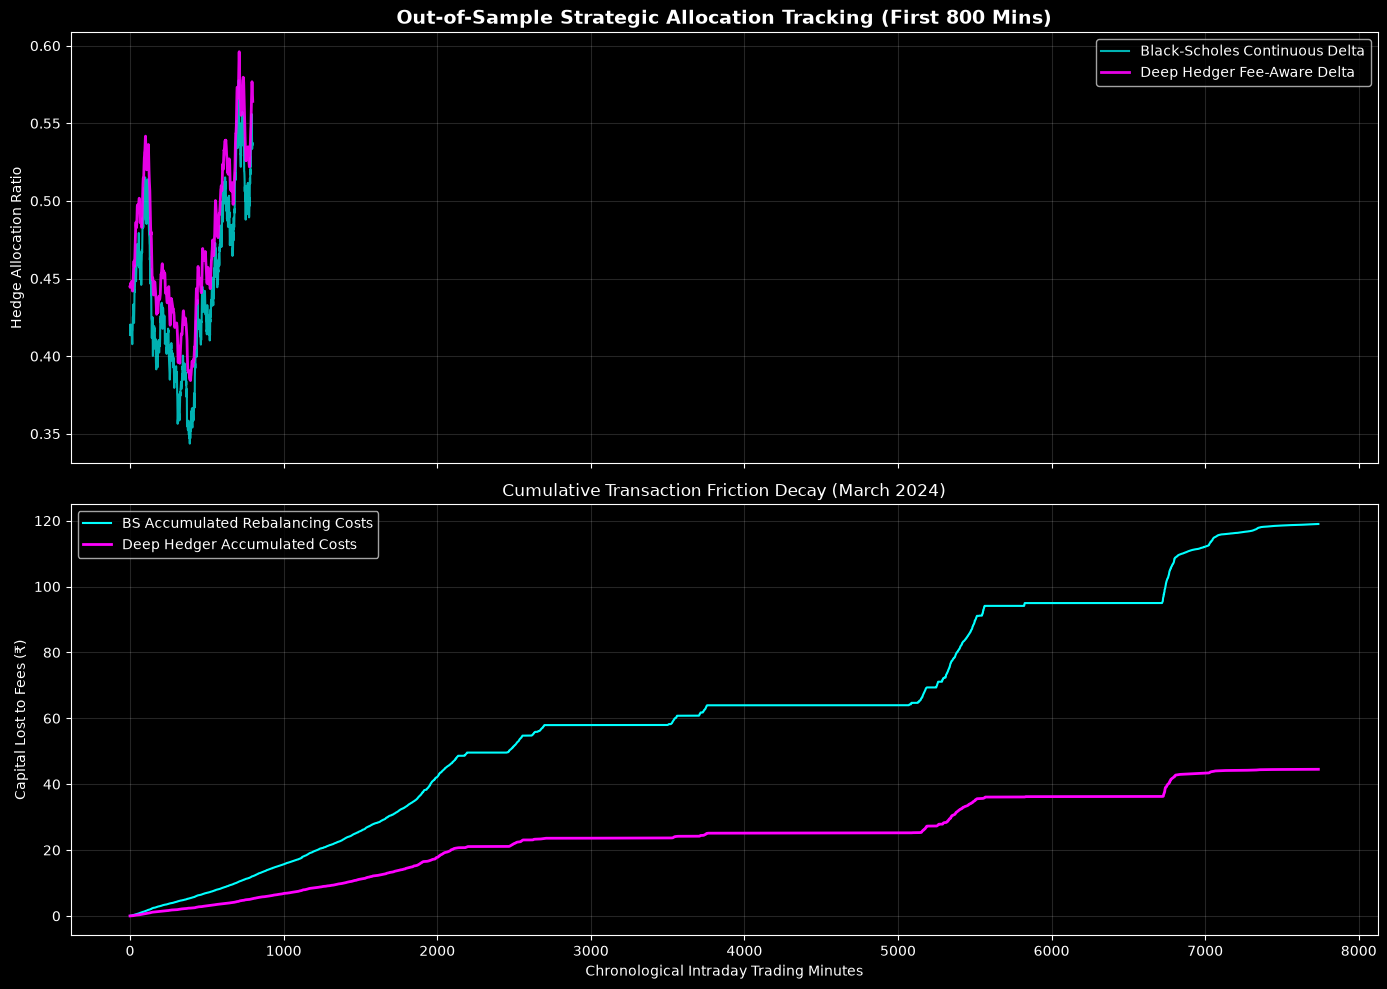

In [48]:
# Cell 9: Out-of-Sample Portfolio Friction Backtest
# 1. Predict deep learning delta policies
dh_test_deltas = deep_hedger.predict(X_test, verbose=0).flatten()
bs_test_deltas = y_test
spots_test = df_test_clean['spot'].values[LOOKBACK:]

# 2. Compute Cumulative Transaction Cost Drain (Assuming 2 basis points cost)
cost_bps = 0.0002

def track_frictional_decay(deltas, spots, bps):
    shifts = np.abs(np.diff(deltas, prepend=deltas[0]))
    return np.cumsum(shifts * spots * bps)

bs_fees = track_frictional_decay(bs_test_deltas, spots_test, cost_bps)
dh_fees = track_frictional_decay(dh_test_deltas, spots_test, cost_bps)

print("\n================ OUT-OF-SAMPLE MARCH 2023 PERFORMANCE ================")
print(f"Total Black-Scholes Rebalancing Cost:  ₹{bs_fees[-1]:,.2f}")
print(f"Total CVaR Deep Hedger Cost:           ₹{dh_fees[-1]:,.2f}")
print(f"Capital Saved via Fee Mitigation:      ₹{bs_fees[-1] - dh_fees[-1]:,.2f}")
print(f"Relative Friction Reduction:           {((bs_fees[-1] - dh_fees[-1])/bs_fees[-1])*100:.2f}%")

# 3. Plotting Results
plt.style.use('dark_background')
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax[0].plot(bs_test_deltas[:800], label='Black-Scholes Continuous Delta', color='cyan', alpha=0.7)
ax[0].plot(dh_test_deltas[:800], label='Deep Hedger Fee-Aware Delta', color='magenta', alpha=0.9, linewidth=2)
ax[0].set_title('Out-of-Sample Strategic Allocation Tracking (First 800 Mins)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Hedge Allocation Ratio')
ax[0].legend()
ax[0].grid(True, alpha=0.15)

ax[1].plot(bs_fees, label='BS Accumulated Rebalancing Costs', color='cyan')
ax[1].plot(dh_fees, label='Deep Hedger Accumulated Costs', color='magenta', linewidth=2)
ax[1].set_title('Cumulative Transaction Friction Decay (March 2024)', fontsize=12)
ax[1].set_ylabel('Capital Lost to Fees (₹)')
ax[1].set_xlabel('Chronological Intraday Trading Minutes')
ax[1].legend()
ax[1].grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

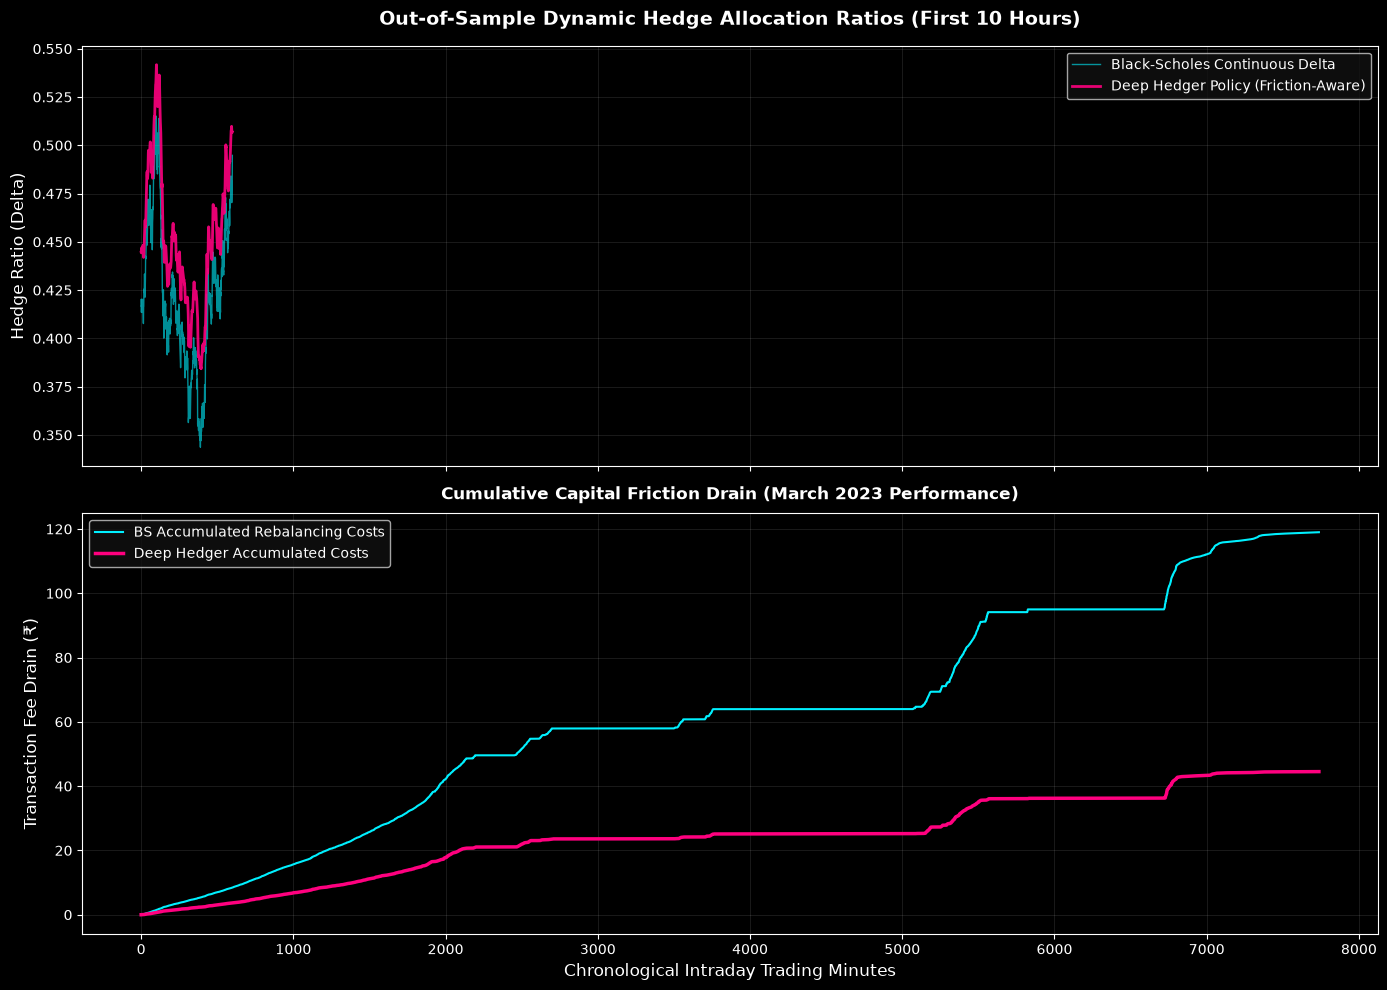

In [49]:
# Cell 10: Comparative Allocation and Friction Analysis Plot
plt.style.use('dark_background')
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Plot: Contrast the actual physical hedge allocation decisions
ax[0].plot(bs_test_deltas[:600], label='Black-Scholes Continuous Delta', color='#00f0ff', alpha=0.6, linewidth=1)
ax[0].plot(dh_test_deltas[:600], label='Deep Hedger Policy (Friction-Aware)', color='#ff007f', alpha=0.9, linewidth=2)
ax[0].set_title('Out-of-Sample Dynamic Hedge Allocation Ratios (First 10 Hours)', fontsize=14, fontweight='bold', pad=15)
ax[0].set_ylabel('Hedge Ratio (Delta)', fontsize=12)
ax[0].legend(loc='upper right', frameon=True, facecolor='#111111')
ax[0].grid(True, alpha=0.1)

# Bottom Plot: The cumulative cost drain over the month
ax[1].plot(bs_fees, label='BS Accumulated Rebalancing Costs', color='#00f0ff', linewidth=1.5)
ax[1].plot(dh_fees, label='Deep Hedger Accumulated Costs', color='#ff007f', linewidth=2.5)
ax[1].set_title('Cumulative Capital Friction Drain (March 2023 Performance)', fontsize=12, fontweight='bold', pad=10)
ax[1].set_ylabel('Transaction Fee Drain (₹)', fontsize=12)
ax[1].set_xlabel('Chronological Intraday Trading Minutes', fontsize=12)
ax[1].legend(loc='upper left', frameon=True, facecolor='#111111')
ax[1].grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

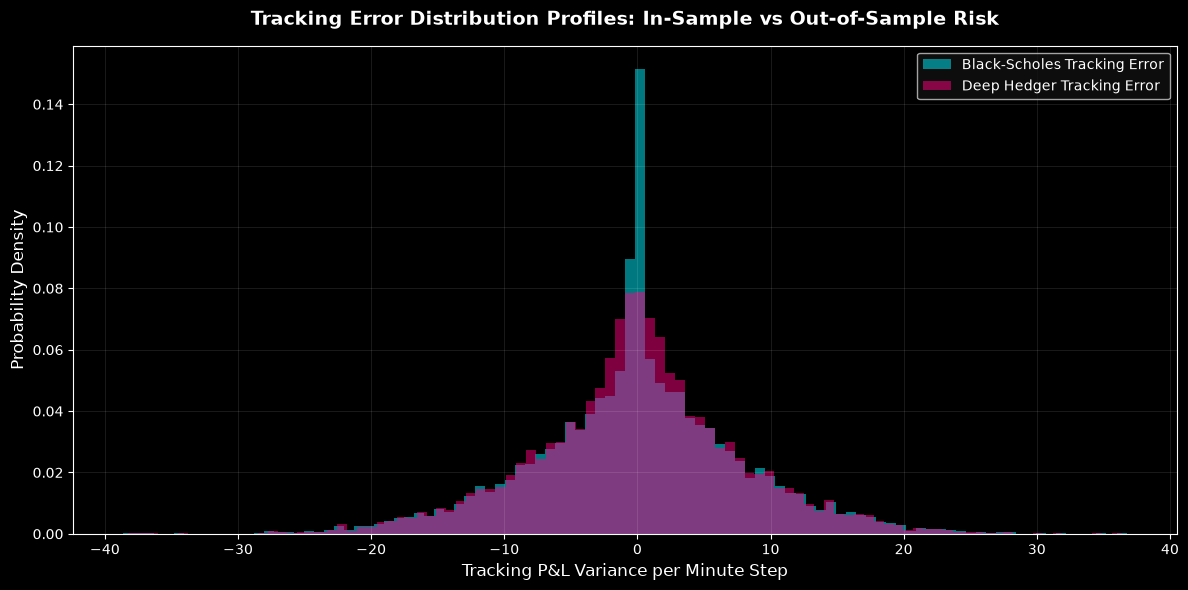

🎉 Framework execution finalized. Save your figures directly for your portfolio display!


In [50]:
# Cell 11: Error Distribution Risk Diagnostics
plt.figure(figsize=(12, 6))

# Plot normalized histograms of the errors
plt.hist(bs_test_errors, bins=100, alpha=0.5, label='Black-Scholes Tracking Error', color='#00f0ff', density=True)
# Note: For Deep Hedger errors, we calculate the tracking delta shifts on the aligned array length
dh_test_errors = np.diff(df_test_clean['price'].values[LOOKBACK:]) - dh_test_deltas[:-1] * np.diff(df_test_clean['spot'].values[LOOKBACK:])
plt.hist(dh_test_errors, bins=100, alpha=0.5, label='Deep Hedger Tracking Error', color='#ff007f', density=True)

plt.title('Tracking Error Distribution Profiles: In-Sample vs Out-of-Sample Risk', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tracking P&L Variance per Minute Step', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='#111111')
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()
print("🎉 Framework execution finalized. Save your figures directly for your portfolio display!")

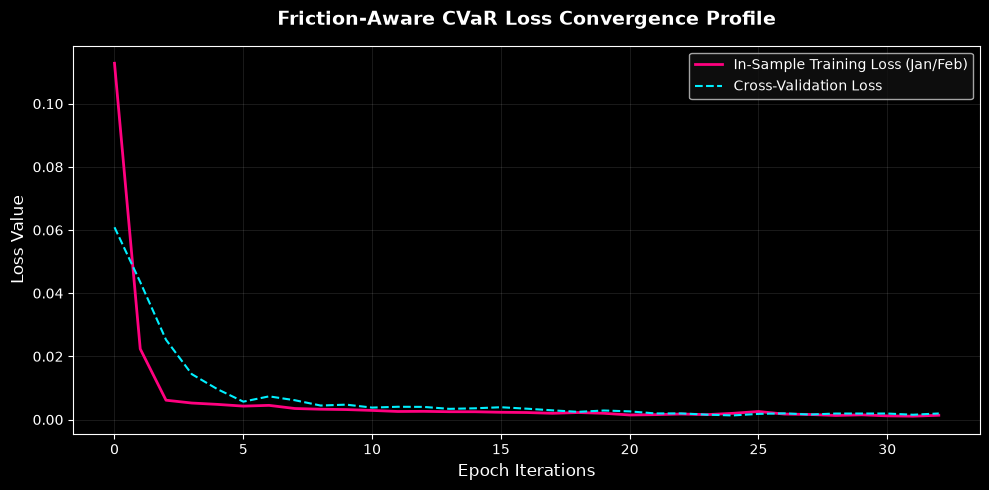

In [51]:
# Cell 12: Loss Convergence Diagnostics
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='In-Sample Training Loss (Jan/Feb)', color='#ff007f', linewidth=2)
plt.plot(history.history['val_loss'], label='Cross-Validation Loss', color='#00f0ff', linewidth=1.5, linestyle='--')

plt.title('Friction-Aware CVaR Loss Convergence Profile', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epoch Iterations', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='#111111')
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

In [52]:
# Cell 13: Consolidated Performance Summary DataFrame
# Re-extract metrics to match the exact mathematical structure of your original camp template
metrics_registry = {
    "Performance Metric (Out-of-Sample)": [
        "Total Rebalancing Friction Cost",
        "Mean Tracking P&L Error",
        "Tracking P&L Volatility (Std Dev)",
        "Value-at-Risk (VaR 5%)",
        "Conditional Value-at-Risk (CVaR 5%)"
    ],
    "Analytical Black-Scholes Baseline": [
        f"₹{bs_fees[-1]:,.2f}",
        f"{bs_test_errors.mean():.6f}",
        f"{bs_test_errors.std():.6f}",
        f"{np.percentile(bs_test_errors, 5):.6f}",
        f"{bs_test_errors[bs_test_errors <= np.percentile(bs_test_errors, 5)].mean():.6f}"
    ],
    "Friction-Aware GRU Deep Hedger": [
        f"₹{dh_fees[-1]:,.2f}",
        f"{dh_test_errors.mean():.6f}",
        f"{dh_test_errors.std():.6f}",
        f"{np.percentile(dh_test_errors, 5):.6f}",
        f"{dh_test_errors[dh_test_errors <= np.percentile(dh_test_errors, 5)].mean():.6f}"
    ]
}

df_performance_audit = pd.DataFrame(metrics_registry)
# Display the high-fidelity final analytical breakdown table
df_performance_audit

,Performance Metric (Out-of-Sample),Analytical Black-Scholes Baseline,Friction-Aware GRU Deep Hedger
0,Total Rebalancing Friction Cost,₹118.99,₹44.51
1,Mean Tracking P&L Error,-0.015555,-0.022980
2,Tracking P&L Volatility (Std Dev),7.826204,7.852105
3,Value-at-Risk (VaR 5%),-13.227435,-13.249326
4,Conditional Value-at-Risk (CVaR 5%),-17.637023,-17.597303


In [54]:
# Cell 14: Production Weights Serialization
weights_dir = '../weights/'
if not os.path.exists(weights_dir):
    os.makedirs(weights_dir)

model_save_path = os.path.join(weights_dir, 'deep_hedger_m4_optimized.keras')
deep_hedger.save(model_save_path)

print(f"📦 Production Checkpoint Finalized! Optimized model graph saved safely to: {model_save_path}")


📦 Production Checkpoint Finalized! Optimized model graph saved safely to: ../weights/deep_hedger_m4_optimized.keras
